# Clustering Workshop
4 clustering algoritmasını kullanarak veri setini kümele
K-Means - Hiyeralik Kümeleme - DBSCan - GMM

['Annual Income (k$)', 'Spending Score (1-100)']


K-Means

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
data = pd.read_csv("dataset/Mall_Customers.csv")
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


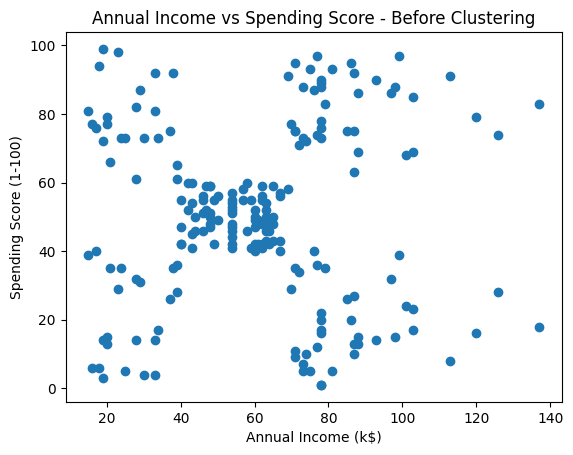

In [44]:
# Kümeleme öncesi veri görselleştirme
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'])
plt.title('Annual Income vs Spending Score - Before Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [3]:
# K-Means algoritması için gerekli olan k değerini belirlemek için Elbow Method kullanacağız.
# Elbow Method
# K değeri için 1-10 arası değerleri deneyeceğiz.
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(data[['Annual Income (k$)', 'Spending Score (1-100)']])
    wcss.append(kmeans.inertia_)

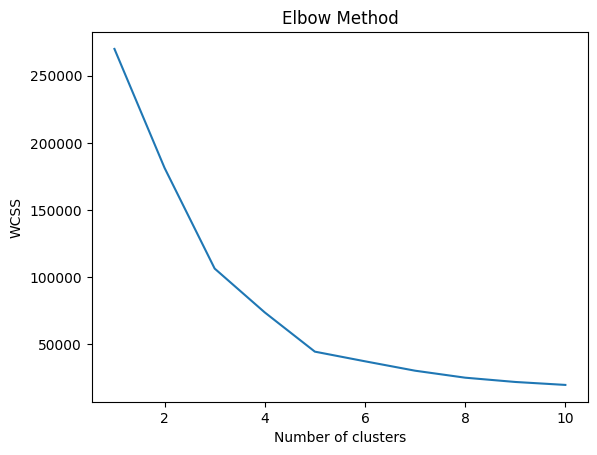

In [4]:
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

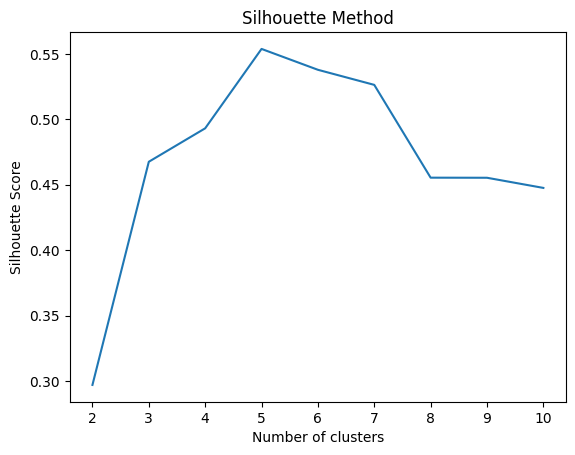

In [37]:
# Siluet Method
from sklearn.metrics import silhouette_score
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(data[['Annual Income (k$)', 'Spending Score (1-100)']])
    silhouette_scores.append(silhouette_score(data[['Annual Income (k$)', 'Spending Score (1-100)']], kmeans.labels_))

plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()


In [5]:
# K değeri 5 olarak belirlendi.
# K-Means algoritmasını uygulayalım.
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(data[['Annual Income (k$)', 'Spending Score (1-100)']])


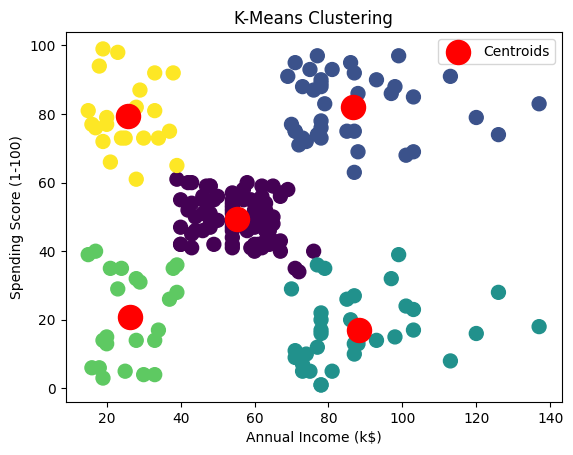

In [6]:
# K-Means algoritmasının sonuçlarını görselleştirelim.
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'], s=100, c=y_kmeans, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], s=300, c='red', label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

Hiyeralik Kümeleme

In [8]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [9]:
# farklı bğalantı türleri için linkage matrisleri hesaplama
linkage_complete = sch.linkage(data[['Annual Income (k$)', 'Spending Score (1-100)']], method='complete')
linkage_single = sch.linkage(data[['Annual Income (k$)', 'Spending Score (1-100)']], method='single')
linkage_average = sch.linkage(data[['Annual Income (k$)', 'Spending Score (1-100)']], method='average')
linkage_centroid = sch.linkage(data[['Annual Income (k$)', 'Spending Score (1-100)']], method='centroid')
linkage_median = sch.linkage(data[['Annual Income (k$)', 'Spending Score (1-100)']], method='median')
linkage_weighted = sch.linkage(data[['Annual Income (k$)', 'Spending Score (1-100)']], method='weighted')

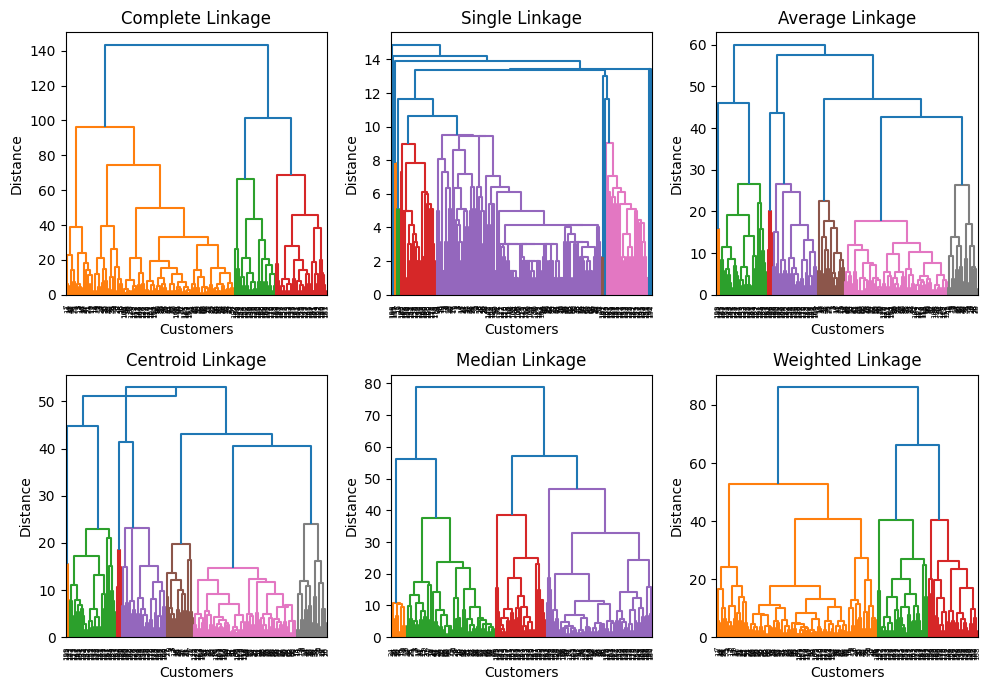

In [11]:
# Dendrogramları çizelim
plt.figure(figsize=(10, 7))
plt.subplot(2, 3, 1)

dendrogram_complete = sch.dendrogram(linkage_complete)
plt.title('Complete Linkage')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.subplot(2, 3, 2)

dendrogram_single = sch.dendrogram(linkage_single)
plt.title('Single Linkage')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.subplot(2, 3, 3)

dendrogram_average = sch.dendrogram(linkage_average)
plt.title('Average Linkage')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.subplot(2, 3, 4)

dendrogram_centroid = sch.dendrogram(linkage_centroid)
plt.title('Centroid Linkage')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.subplot(2, 3, 5)

dendrogram_median = sch.dendrogram(linkage_median)
plt.title('Median Linkage')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.subplot(2, 3, 6)

dendrogram_weighted = sch.dendrogram(linkage_weighted)
plt.title('Weighted Linkage')
plt.xlabel('Customers')
plt.ylabel('Distance')

plt.tight_layout()
plt.show()

In [13]:
# Agglomerative Clustering kullanarak Kümeleme ( örneğin ward bağltanısı ve 3 küme )
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_hc = hc.fit_predict(data[['Annual Income (k$)', 'Spending Score (1-100)']])

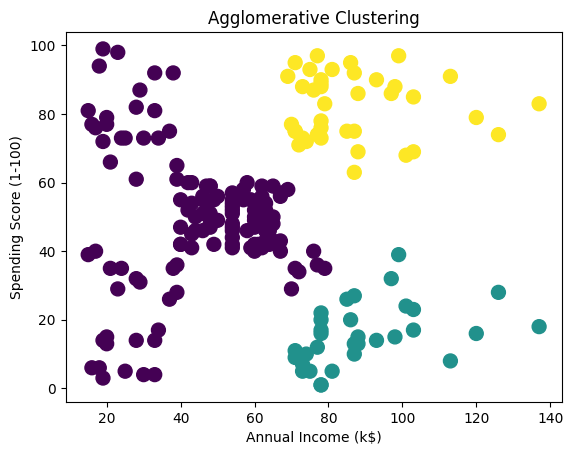

In [14]:
# Kümeleme Sonuçlarını Görselleştirme
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'], s=100, c=y_hc, cmap='viridis')
plt.title('Agglomerative Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

DBScan

In [15]:
# 1. Epsilon (eps) seçimi için K-Mesafe Grafiği
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as pl
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

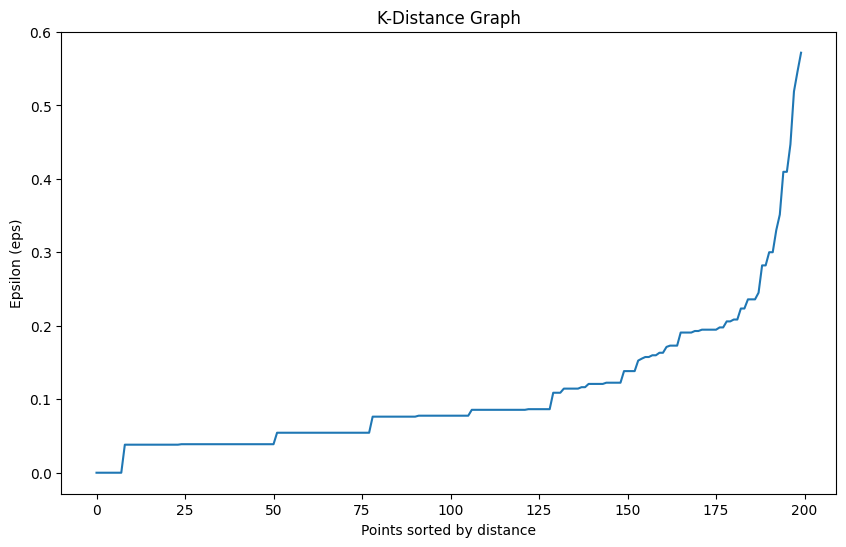

In [16]:
# 1. Epsilon (eps) seçimi için K-Mesafe Grafiği
# Veriyi ölçeklendirme
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[['Annual Income (k$)', 'Spending Score (1-100)']])
# K-Mesafe grafiği için en yakın komşuları bulma
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(data_scaled)
distances, indices = neighbors.kneighbors(data_scaled)
# Mesafeleri sıralama
distances = np.sort(distances, axis=0)
distances = distances[:, 1]
# K-Mesafe grafiğini çizme
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-Distance Graph')
plt.xlabel('Points sorted by distance')
plt.ylabel('Epsilon (eps)')
plt.show()

In [17]:
# 2. DBSCAN Uygulaması (tahmini eps ve minPts=3 ile)
dbscan = DBSCAN(eps=0.5, min_samples=3)
y_dbscan = dbscan.fit_predict(data_scaled)

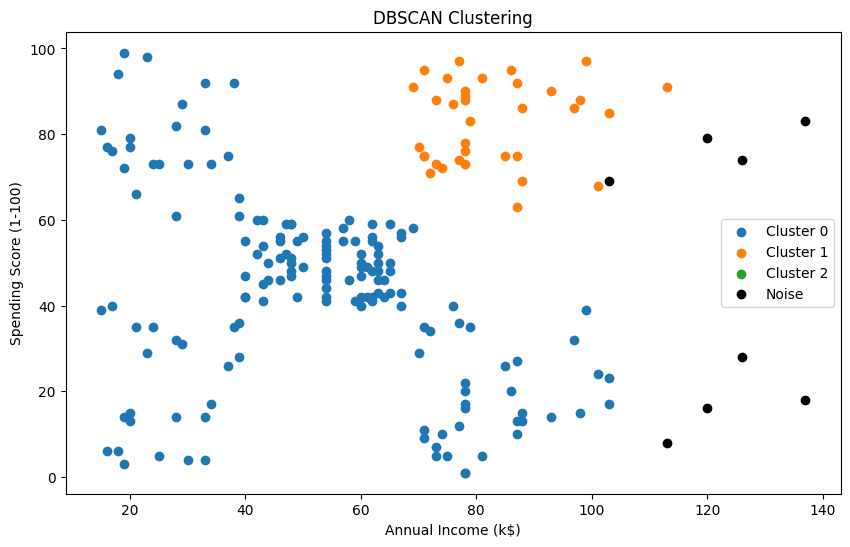

In [34]:
# Sonuçları görselleştirme
plt.figure(figsize=(10, 6))
for i in range(len(set(y_dbscan))):
    plt.scatter(data.loc[y_dbscan == i, 'Annual Income (k$)'], data.loc[y_dbscan == i, 'Spending Score (1-100)'], label=f'Cluster {i}')
plt.scatter(data.loc[y_dbscan == -1, 'Annual Income (k$)'], data.loc[y_dbscan == -1, 'Spending Score (1-100)'], c='black', label='Noise')
plt.title('DBSCAN Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

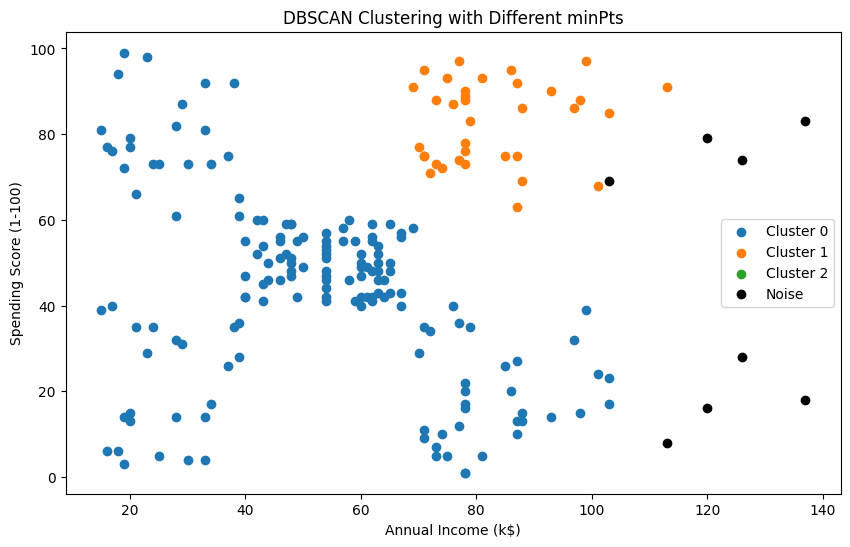

In [33]:
# 3. DBSCAN Uygulaması (farklı minPts ile)
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(data_scaled)

# Alternatif sonuçları görselleştirme
plt.figure(figsize=(10, 6))
for i in range(len(set(y_dbscan))):
    plt.scatter(data.loc[y_dbscan == i, 'Annual Income (k$)'], data.loc[y_dbscan == i, 'Spending Score (1-100)'], label=f'Cluster {i}')
plt.scatter(data.loc[y_dbscan == -1, 'Annual Income (k$)'], data.loc[y_dbscan == -1, 'Spending Score (1-100)'], c='black', label='Noise')
plt.title('DBSCAN Clustering with Different minPts')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [21]:
# Küme etiketlerini yazdırma
print("DBSCAN Cluster Labels:")
print(y_dbscan)

DBSCAN Cluster Labels:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0 -1
 -1  1 -1 -1 -1 -1 -1 -1]


Gaussian Mixture Model (GMM)

In [22]:
import seaborn as sns
from sklearn.mixture import GaussianMixture

In [27]:
# GMM modelini oluşturma ve eğitme
gmm = GaussianMixture(n_components=5, random_state=0)
gmm.fit(data[['Annual Income (k$)', 'Spending Score (1-100)']])
# Küme etiketlerini tahmin etme
labels = gmm.predict(data[['Annual Income (k$)', 'Spending Score (1-100)']])
probabilities = gmm.predict_proba(data[['Annual Income (k$)', 'Spending Score (1-100)']])

# Gauss bileşenlerinin parametrelerini alma
means = gmm.means_
covariances = gmm.covariances_

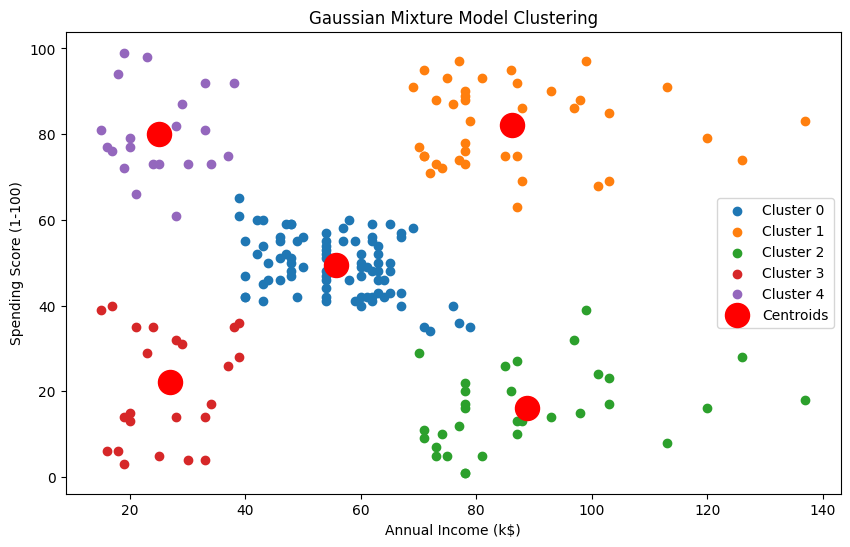

In [29]:
# Sonuçları görselleştirme
plt.figure(figsize=(10, 6))
for i in range(gmm.n_components):
    plt.scatter(data.loc[labels == i, 'Annual Income (k$)'], data.loc[labels == i, 'Spending Score (1-100)'], label=f'Cluster {i}')
plt.scatter(means[:, 0], means[:, 1], s=300, c='red', label='Centroids')
plt.title('Gaussian Mixture Model Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


Kümele Algoritmaları Karşılaştırma Grafikleri

In [ ]:
 # Tüm kümeleme algoritmalarını karşılaştırma
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'], s=100, c=y_kmeans, cmap='viridis')
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.subplot(2, 2, 2)
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'], s=100, c=y_hc, cmap='viridis')
plt.title('Agglomerative Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.subplot(2, 2, 3)
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'], s=100, c=y_dbscan, cmap='viridis')
plt.title('DBSCAN Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.subplot(2, 2, 4)
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'], s=100, c=labels, cmap='viridis')
plt.title('Gaussian Mixture Model Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.show()